
# Consistência entre Metropolis, Wolff e Swendsen-Wang

Material de apoio ao TCC: Comparação e Otimização de Algoritmos de Monte
Carlo Aplicados ao Modelo de Ising (Diego R. Oliveira, UFPR).

Este notebook não roda nenhuma simulação nova. Ele carrega os arquivos
`.npz` que já foram salvos pelos três notebooks de simulação (Metropolis,
Wolff e Swendsen-Wang) e faz a comparação cruzada descrita na Seção 4.4.2
do TCC. A ideia por trás desse teste é simples: Os três algoritmos
amostram o mesmo ensemble canônico, então para um mesmo tamanho de rede e
uma mesma temperatura, as médias de energia e magnetização obtidas pelos
três devem coincidir dentro da incerteza estatística de cada uma. Se um
dos três destoar dos outros dois de forma significativa, isso é um sinal
de que algo está errado em alguma das implementações.


In [1]:

import os
from google.colab import drive

drive.mount('/content/drive')

assert os.path.ismount('/content/drive'), (
    "ERRO. Google Drive nao esta montado de verdade. "
    "Nao prossiga ate resolver isso."
)
print("Drive confirmado como montado corretamente.")


Mounted at /content/drive
Drive confirmado como montado corretamente.


In [2]:

!git clone https://github.com/diegorafael1010/ising-monte-carlo.git


Cloning into 'ising-monte-carlo'...
remote: Enumerating objects: 38, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 38 (delta 17), reused 21 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (38/38), 60.73 KiB | 4.05 MiB/s, done.
Resolving deltas: 100% (17/17), done.


In [3]:

import glob
import re

import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('/content/ising-monte-carlo')
from ising_utils import energia_onsager, magnetizacao_onsager, temperatura_critica_onsager

PASTA_DADOS = '/content/drive/MyDrive/0_TCC_Diego/dados'



## Carregando os dados dos três algoritmos

A função abaixo procura, para um algoritmo específico, todos os arquivos
`.npz` salvos na pasta de dados e devolve um dicionário organizado por
tamanho de rede e temperatura. Ela é a mesma lógica usada no script de
gráficos que já rodamos antes, só que agora vamos chamá-la três vezes, uma
para cada algoritmo, e depois cruzar os resultados.

O erro de cada média usa o tempo de autocorrelação integrado, calculado
no notebook de autocorrelação e salvo em um arquivo de resumo, seguindo a
Equação 4.38 do TCC. Por isso, antes de rodar este notebook, o notebook
de autocorrelação precisa já ter sido executado ao menos uma vez.


In [4]:

import json

with open(f'{PASTA_DADOS}/resumo_autocorrelacao.json') as arquivo:
    resumo_autocorrelacao = json.load(arquivo)


def buscar_erro_corrigido(algoritmo, L, T):
    for chave, valores in resumo_autocorrelacao.items():
        alg_chave, L_chave, T_chave = chave.split('|')
        if alg_chave == algoritmo and int(L_chave) == L and abs(float(T_chave) - T) < 1e-6:
            return valores['e_erro_correto'], valores['m_erro_correto']
    return None, None


def carregar_dados_algoritmo(algoritmo, pasta_dados):
    padrao = os.path.join(pasta_dados, f'{algoritmo}_L*_T*.npz')
    arquivos = sorted(glob.glob(padrao))
    regex_nome = re.compile(rf'{algoritmo}_L(\d+)_T([\d.]+)\.npz$')

    dados = {}
    for caminho in arquivos:
        nome = os.path.basename(caminho)
        m = regex_nome.search(nome)
        if not m:
            continue
        L = int(m.group(1))
        T = float(m.group(2))

        conteudo = np.load(caminho)
        energia = conteudo['energia']
        magnetizacao = conteudo['magnetizacao']

        e_erro, m_erro = buscar_erro_corrigido(algoritmo, L, T)
        if e_erro is None:
            raise ValueError(
                f"Nao encontrei o erro corrigido para {algoritmo}, L igual a {L}, "
                f"T igual a {T}. Confirme que o notebook de autocorrelacao ja rodou "
                f"e salvou o resumo para esta combinacao."
            )

        dados[(L, T)] = {
            'e_media': energia.mean(), 'e_erro': e_erro,
            'm_media': magnetizacao.mean(), 'm_erro': m_erro,
            'n_amostras': len(energia),
        }
    return dados


In [6]:

dados_metropolis = carregar_dados_algoritmo('metropolis', PASTA_DADOS)
dados_wolff = carregar_dados_algoritmo('wolff', PASTA_DADOS)
dados_sw = carregar_dados_algoritmo('swendsen_wang', PASTA_DADOS)

print(f"Metropolis, {len(dados_metropolis)} combinacoes carregadas")
print(f"Wolff, {len(dados_wolff)} combinacoes carregadas")
print(f"Swendsen Wang, {len(dados_sw)} combinacoes carregadas")

combinacoes_comuns = sorted(set(dados_metropolis) & set(dados_wolff) & set(dados_sw))
print(f"\nCombinacoes presentes nos tres algoritmos ao mesmo tempo, {len(combinacoes_comuns)}")
if len(combinacoes_comuns) < 20:
    print("Atencao. Esperado 20 combinacoes (4 tamanhos de rede x 5 temperaturas).")
    print("Confira se todos os notebooks de simulacao ja terminaram de rodar.")


Metropolis, 20 combinacoes carregadas
Wolff, 20 combinacoes carregadas
Swendsen Wang, 20 combinacoes carregadas

Combinacoes presentes nos tres algoritmos ao mesmo tempo, 20



## Comparando os três algoritmos, dois a dois

Para cada combinação de tamanho de rede e temperatura, comparamos os três
algoritmos em pares (Metropolis com Wolff, Metropolis com Swendsen-Wang, e
Wolff com Swendsen-Wang). Para cada par, calculamos quantos desvios padrão
combinados separam as duas médias, usando a fórmula

$$n_\sigma = \frac{|\bar{A} \bar{B}|}{\sqrt{\sigma_A^2 + \sigma_B^2}}$$

O critério adotado na Seção 4.4.2 do TCC considera os resultados
consistentes quando essa razão fica abaixo de dois. Isso vale tanto para a
energia quanto para a magnetização.


In [7]:

def numero_de_sigmas(media_a, erro_a, media_b, erro_b):
    sigma_combinado = np.sqrt(erro_a**2 + erro_b**2)
    if sigma_combinado == 0:
        return 0.0
    return abs(media_a - media_b) / sigma_combinado


pares = [
    ('Metropolis', dados_metropolis, 'Wolff', dados_wolff),
    ('Metropolis', dados_metropolis, 'Swendsen Wang', dados_sw),
    ('Wolff', dados_wolff, 'Swendsen Wang', dados_sw),
]

linhas_resultado = []
for L, T in combinacoes_comuns:
    linha = {'L': L, 'T': T}
    todas_consistentes = True
    for nome_a, dic_a, nome_b, dic_b in pares:
        a = dic_a[(L, T)]
        b = dic_b[(L, T)]

        sig_e = numero_de_sigmas(a['e_media'], a['e_erro'], b['e_media'], b['e_erro'])
        sig_m = numero_de_sigmas(a['m_media'], a['m_erro'], b['m_media'], b['m_erro'])

        chave = f"{nome_a[:3]}_{nome_b[:3]}"
        linha[f'{chave}_sigma_e'] = sig_e
        linha[f'{chave}_sigma_m'] = sig_m

        if sig_e >= 2.0 or sig_m >= 2.0:
            todas_consistentes = False

    linha['consistente'] = todas_consistentes
    linhas_resultado.append(linha)

n_consistentes = sum(1 for l in linhas_resultado if l['consistente'])
print(f"Combinacoes dentro do criterio de dois sigma nos tres pares, "
      f"{n_consistentes} de {len(linhas_resultado)}")


Combinacoes dentro do criterio de dois sigma nos tres pares, 16 de 20



## Tabela detalhada

A tabela abaixo mostra, para cada combinação, o maior valor de sigma
encontrado entre os três pares e as duas grandezas (energia e
magnetização). Esse número único facilita ver rapidamente quais
combinações merecem uma segunda olhada.


In [8]:

print(f"{'L':>5} {'T':>7} {'sigma maximo':>14} {'status':>14}")
print("_" * 45)

for linha in linhas_resultado:
    colunas_sigma = [v for k, v in linha.items() if 'sigma' in k]
    sigma_max = max(colunas_sigma)
    status = "ok" if linha['consistente'] else "verificar"
    print(f"{linha['L']:>5} {linha['T']:>7.3f} {sigma_max:>14.2f} {status:>14}")


    L       T   sigma maximo         status
_____________________________________________
   16   1.500           2.35      verificar
   16   2.000           1.35             ok
   16   2.269           3.28      verificar
   16   2.500           1.25             ok
   16   3.000           1.65             ok
   32   1.500           1.45             ok
   32   2.000           1.82             ok
   32   2.269           1.88             ok
   32   2.500           2.49      verificar
   32   3.000           1.97             ok
   64   1.500           1.70             ok
   64   2.000           2.20      verificar
   64   2.269           1.76             ok
   64   2.500           1.73             ok
   64   3.000           1.07             ok
  128   1.500           0.97             ok
  128   2.000           0.88             ok
  128   2.269           1.62             ok
  128   2.500           1.18             ok
  128   3.000           1.12             ok



## Gráfico comparativo

O gráfico abaixo mostra os três algoritmos sobrepostos na mesma curva de
Onsager, com uma cor para cada método. Se tudo estiver consistente, os
três conjuntos de pontos devem se sobrepor de forma bem próxima em cada
temperatura, sem nenhum algoritmo sistematicamente deslocado dos outros
dois.


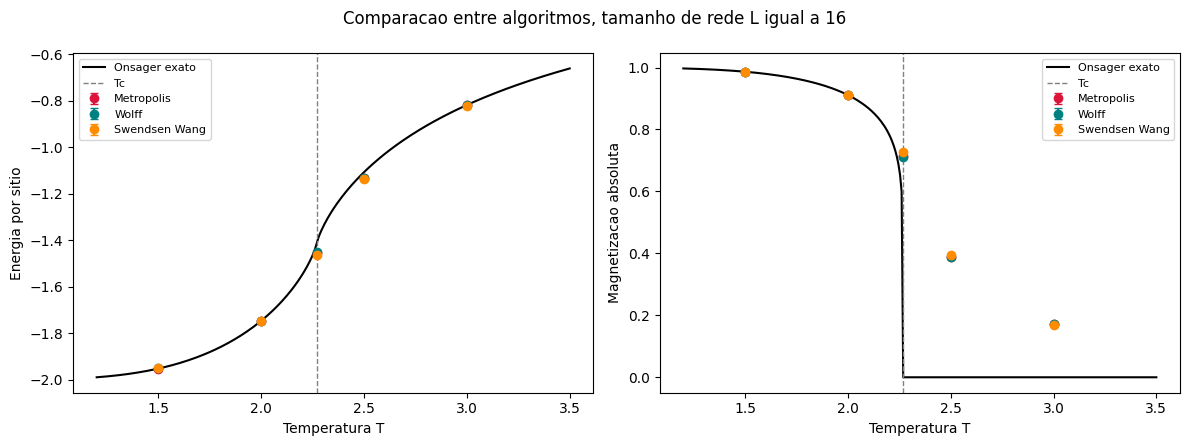

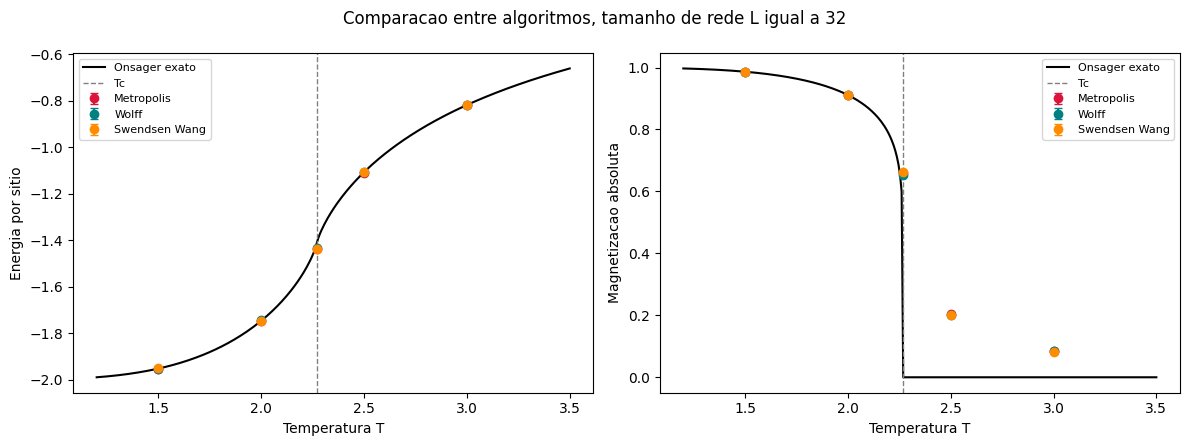

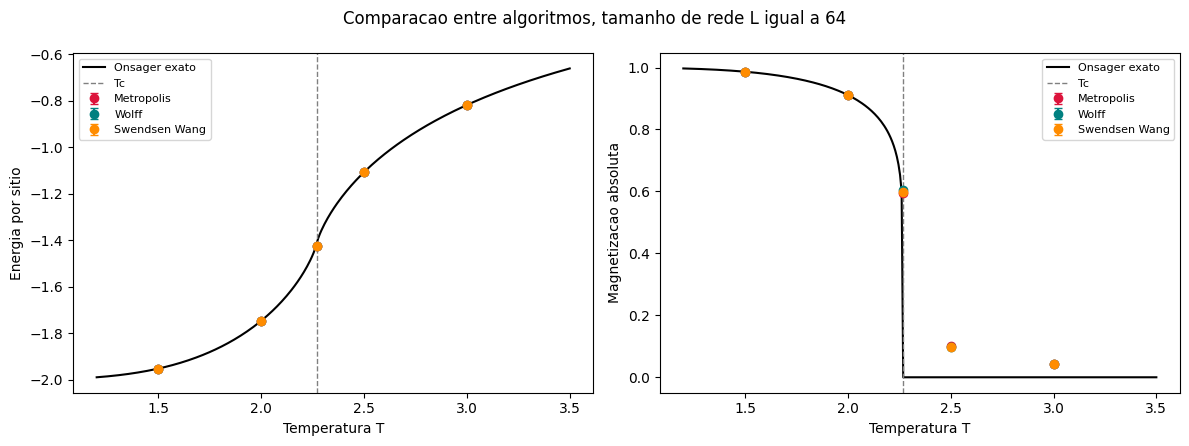

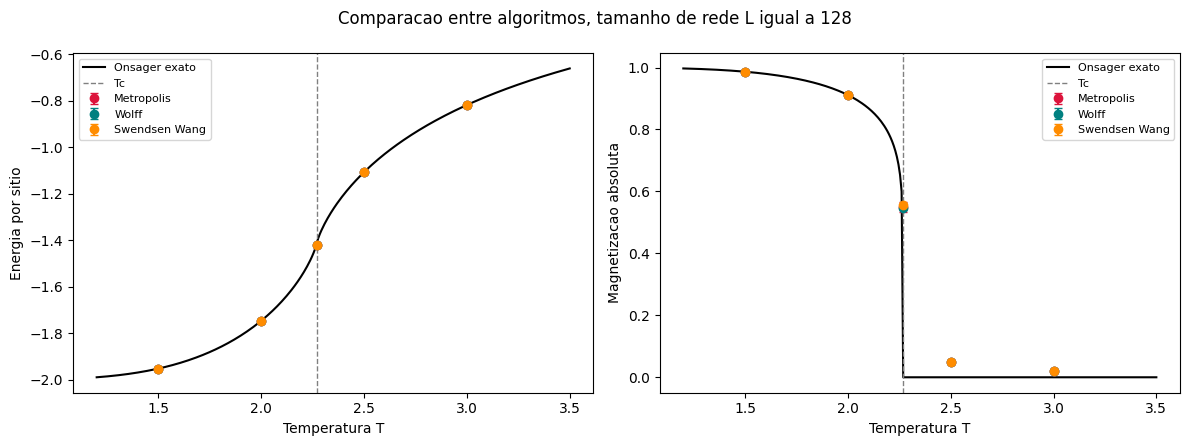

In [9]:

L_para_plotar = sorted(set(L for L, T in combinacoes_comuns))

cores_algoritmo = {'Metropolis': 'crimson', 'Wolff': 'teal', 'Swendsen Wang': 'darkorange'}
dados_algoritmo = {'Metropolis': dados_metropolis, 'Wolff': dados_wolff, 'Swendsen Wang': dados_sw}

T_fino = np.linspace(1.2, 3.5, 300)
e_exato = np.array([energia_onsager(T) for T in T_fino])
m_exato = np.array([magnetizacao_onsager(T) for T in T_fino])
Tc = temperatura_critica_onsager()

for L in L_para_plotar:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

    ax1.plot(T_fino, e_exato, color='black', lw=1.5, label='Onsager exato')
    ax2.plot(T_fino, m_exato, color='black', lw=1.5, label='Onsager exato')

    for nome_algo, dic in dados_algoritmo.items():
        Ts = sorted(T for (Lc, T) in dic if Lc == L)
        e_medias = [dic[(L, T)]['e_media'] for T in Ts]
        e_erros = [dic[(L, T)]['e_erro'] for T in Ts]
        m_medias = [dic[(L, T)]['m_media'] for T in Ts]
        m_erros = [dic[(L, T)]['m_erro'] for T in Ts]

        cor = cores_algoritmo[nome_algo]
        ax1.errorbar(Ts, e_medias, yerr=e_erros, fmt='o', color=cor, capsize=3, label=nome_algo)
        ax2.errorbar(Ts, m_medias, yerr=m_erros, fmt='o', color=cor, capsize=3, label=nome_algo)

    for ax, rotulo_y in ((ax1, 'Energia por sitio'), (ax2, 'Magnetizacao absoluta')):
        ax.axvline(Tc, ls='--', color='gray', lw=1, label='Tc')
        ax.set_xlabel('Temperatura T')
        ax.set_ylabel(rotulo_y)
        ax.legend(fontsize=8)

    fig.suptitle(f'Comparacao entre algoritmos, tamanho de rede L igual a {L}')
    plt.tight_layout()
    plt.savefig(os.path.join(PASTA_DADOS, f'consistencia_L{L}.png'), dpi=150)
    plt.show()



## O que fazer com este resultado

Se a grande maioria das combinacoes passou no criterio, isso da uma boa
base para afirmar, na Secao 4.4.2 do TCC, que as tres implementacoes
convergem para o mesmo ensemble de equilibrio, como esperado fisicamente.
Vale colar a tabela (ou uma versao resumida dela) direto no texto da
secao de Resultados.

Se alguma combinacao especifica ficou fora do criterio, vale investigar a
implementacao daquele algoritmo naquela combinacao especifica antes de
seguir em frente.
